In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
def wrangle(path):

    ##Loading the CSV file
    df = pd.read_csv(path)

    ##Adding required monthly savings column
    df["Required_Monthly_Savings"] = df["Target_Amount"] / df["Timeline_Months"]

    return df

In [3]:
##Loading the dataset
df= wrangle("C:/Users/Administrator/Documents/My Documents/my_school_project/data/financial_dataset.csv")
df.head()


,User_ID,Monthly_Income,Housing,Food,Transport,Entertainment,Subscriptions,Utilities,Monthly_Savings,Total_Debt,Goal_Type,Target_Amount,Timeline_Months,Total_Expenses,Savings_Rate,Debt_to_Income,Required_Monthly_Savings
0,1,151958,11910,25671,18990,11457,8582,9662,57091,111317,Business,538545,14,86272,0.375702,0.732551,38467.500000
1,2,176867,5206,28199,2699,24001,4671,9120,21949,139789,Travel,849735,28,73896,0.124099,0.790362,30347.678571
2,3,161932,28419,12208,2190,3479,4860,8114,70080,389593,House,210279,15,59270,0.432774,2.405905,14018.600000
3,4,289178,55636,19371,12492,23868,3002,14323,37744,290843,House,750406,42,128692,0.130522,1.005758,17866.809524
4,5,149879,55015,14835,19364,24805,1217,2353,45543,73686,Car,704647,20,117589,0.303865,0.491637,35232.350000


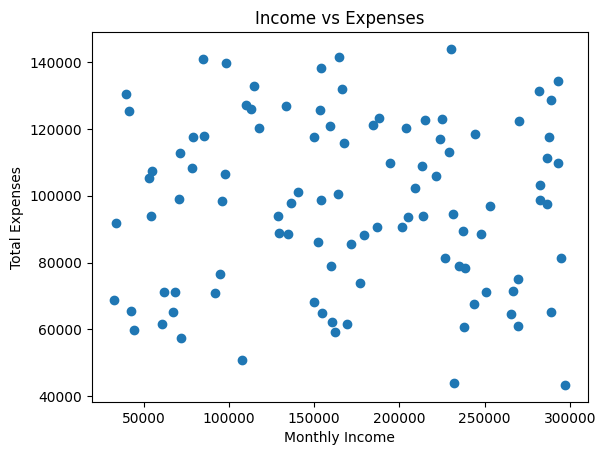

In [4]:
##Scatter plot to show Income vs Expenses
plt.figure()
plt.scatter(df["Monthly_Income"], df["Total_Expenses"])
plt.xlabel("Monthly Income")
plt.ylabel("Total Expenses")
plt.title("Income vs Expenses")
plt.show()

The scatter plot of monthly income against total expenses reveals no strong linear relationship between the two variables. Users with similar income levels exhibit significant variation in their spending patterns, indicating that financial behavior differs across individuals. While some users maintain relatively lower expenses compared to their income, others exhibit higher spending levels, suggesting potential overspending tendencies. This variation supports the need to analyze behavioral patterns in financial decision-making rather than relying solely on income as a determinant.

In [5]:
## Spending behavior analysis
df["Spending_Ratio"] = df["Total_Expenses"] / df["Monthly_Income"]

## Classification of spending behavior
conditions = [
    df["Spending_Ratio"] < 0.7,
    (df["Spending_Ratio"] >= 0.7) & (df["Spending_Ratio"] <= 0.9),
    df["Spending_Ratio"] > 0.9
]

labels = ["Controlled Spender", "Moderate Spender", "High Spender"]

df["Spending_Behavior"] = np.select(conditions, labels, default="Unknown")

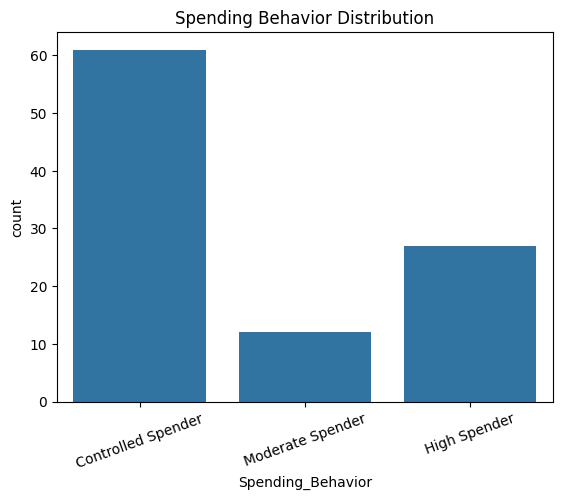

In [6]:
##Visualization of Spending Behavior Distribution
plt.figure()
sns.countplot(x="Spending_Behavior", data=df)
plt.title("Spending Behavior Distribution")
plt.xticks(rotation=20)
plt.show()

The distribution of spending behavior indicates that the majority of users are controlled spenders, suggesting relatively disciplined financial habits. However, a significant proportion of users are classified as high spenders, indicating a tendency to allocate a large share of their income toward expenses. The moderate spender category contains the fewest users, suggesting that individuals tend to exhibit either conservative or high spending behaviors rather than balanced spending patterns. This variation highlights the presence of distinct financial behavior groups, supporting the need for user segmentation and personalized financial recommendations.

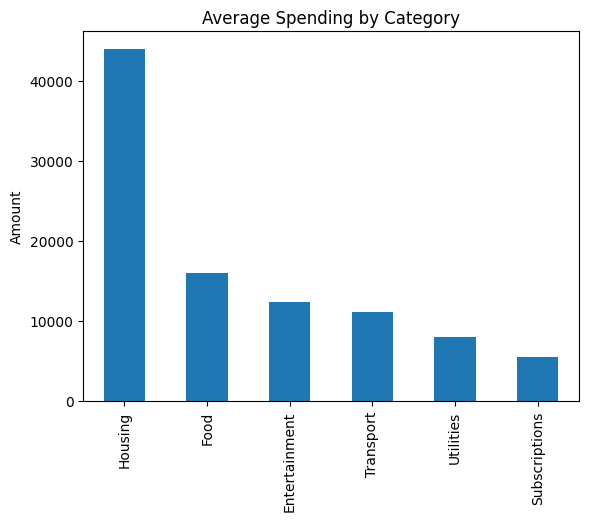

In [7]:
## Average spending by category
expense_cols = ["Housing", "Food", "Transport", "Entertainment", "Subscriptions", "Utilities"]

df[expense_cols].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Spending by Category")
plt.ylabel("Amount")
plt.show()

The analysis of average spending across categories reveals that housing constitutes the largest proportion of user expenses, followed by food. These essential expenses consume a significant share of income, limiting the capacity for savings. Other categories such as transport, entertainment, and utilities represent moderate expenditures and may offer opportunities for cost optimization. Subscriptions account for the lowest spending but may still contribute to unnecessary financial leakage over time. This distribution highlights the distinction between essential and discretionary spending, which is critical for developing targeted financial recommendations.

    User_ID  Monthly_Income  Monthly_Savings  Savings_Rate
27       28           32747            37441      1.143341
34       35           33890            73553      2.170345
61       62           41534            71774      1.728078
70       71           39268            75697      1.927702
93       94           54538            64291      1.178829
Remaining users after cleaning: 95


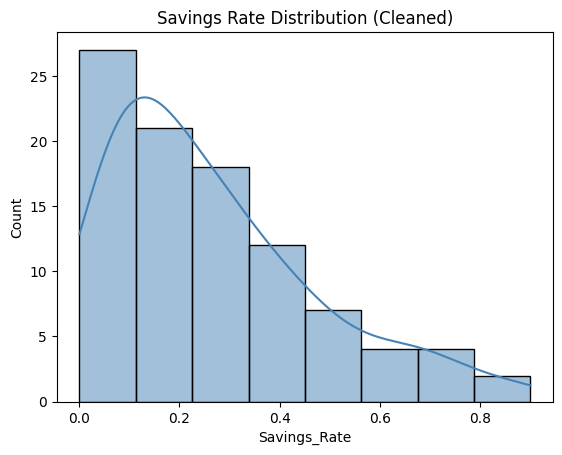

In [8]:
## Check for savings rates above 100%(Outliers that need to be removed before clustering)

# See exactly who has a savings rate above 100%
print(df[df["Savings_Rate"] > 1.0][["User_ID", "Monthly_Income", "Monthly_Savings", "Savings_Rate"]])

# Remove them
df = df[df["Savings_Rate"] <= 1.0].reset_index(drop=True)

print(f"Remaining users after cleaning: {len(df)}")

# Replot to confirm
sns.histplot(df["Savings_Rate"], kde=True, color="steelblue")
plt.title("Savings Rate Distribution (Cleaned)")
plt.xlabel("Savings_Rate")
plt.ylabel("Count")
plt.show()

The savings rate distribution is strongly right-skewed, with the majority of users saving between 0% and 30% of their monthly income. The modal savings rate falls below 10%, indicating that most users in the sample are under-saving relative to the recommended 20% benchmark. A small number of anomalous records with savings rates exceeding 1.0 were identified as simulation artifacts and removed prior to further analysis.

Removed 5 users whose savings rate were more than 1.0 (Outliers)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   User_ID                   95 non-null     int64  
 1   Monthly_Income            95 non-null     int64  
 2   Housing                   95 non-null     int64  
 3   Food                      95 non-null     int64  
 4   Transport                 95 non-null     int64  
 5   Entertainment             95 non-null     int64  
 6   Subscriptions             95 non-null     int64  
 7   Utilities                 95 non-null     int64  
 8   Monthly_Savings           95 non-null     int64  
 9   Total_Debt                95 non-null     int64  
 10  Goal_Type                 95 non-null     object 
 11  Target_Amount             95 non-null     int64  
 12  Timeline_Months           95 non-null     int64  
 13  Total_Expenses            95 non-null     int64  
 14  Savings_Rate

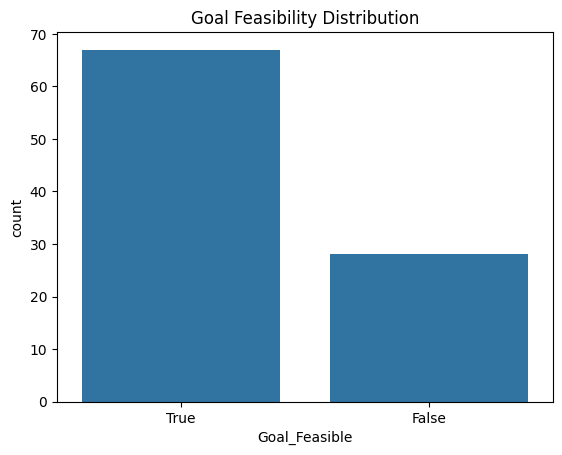

In [10]:
df["Goal_Feasible"] = df["Monthly_Savings"] >= df["Required_Monthly_Savings"]

sns.countplot(x="Goal_Feasible", data=df, order=df["Goal_Feasible"].value_counts().index)
plt.title("Goal Feasibility Distribution")
plt.show()

Goal feasibility analysis reveals that approximately 67% of users possess sufficient monthly surplus to achieve their financial goals within the stated timeline, while 33% face a feasibility gap. This finding highlights a significant portion of users who require targeted recommendations to either increase savings, reduce expenditure, or adjust their goal parameters.

In [11]:
# Features needed for clustering
df["Spending_Ratio"] = df["Total_Expenses"] / df["Monthly_Income"]
df["Discretionary_Ratio"] = (df["Entertainment"] + df["Subscriptions"]) / df["Monthly_Income"]
df["Subscription_Ratio"] = df["Subscriptions"] / df["Monthly_Income"]

print(df[["Savings_Rate", "Debt_to_Income", "Spending_Ratio", 
          "Discretionary_Ratio", "Subscription_Ratio"]].describe())

       Savings_Rate  Debt_to_Income  Spending_Ratio  Discretionary_Ratio  \
count     95.000000       95.000000       95.000000            95.000000   
mean       0.263281        1.648522        0.679916             0.129462   
std        0.207827        1.454630        0.399714             0.100348   
min        0.000427        0.036489        0.145807             0.016413   
25%        0.091833        0.592690        0.387813             0.066853   
50%        0.221523        1.238585        0.521964             0.098453   
75%        0.363399        2.319168        0.837884             0.149377   
max        0.899953        8.974684        1.975623             0.565384   

       Subscription_Ratio  
count           95.000000  
mean             0.040944  
std              0.035112  
min              0.003259  
25%              0.016712  
50%              0.032118  
75%              0.051027  
max              0.186583  


In [12]:
from sklearn.preprocessing import StandardScaler

features = ["Savings_Rate", "Debt_to_Income", "Spending_Ratio", 
            "Discretionary_Ratio", "Subscription_Ratio"]

scaler = StandardScaler()
X = scaler.fit_transform(df[features])

print("Scaling done ✅ Shape:", X.shape)

Scaling done ✅ Shape: (95, 5)


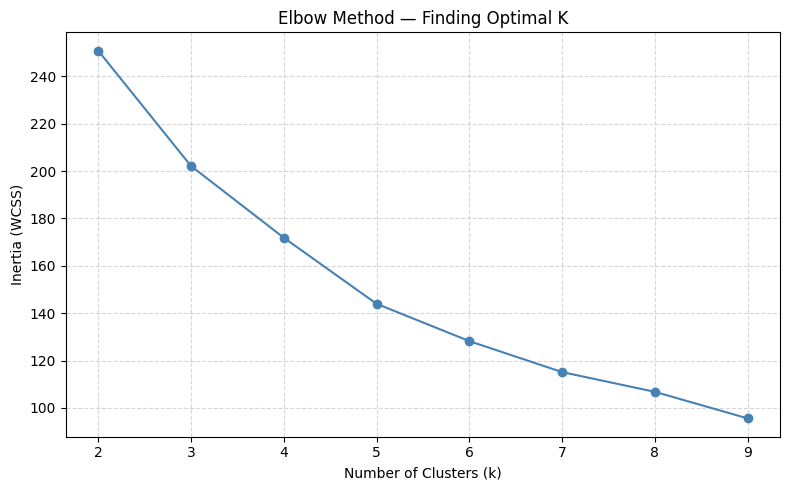

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.title("Elbow Method — Finding Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

k=2 → Silhouette Score: 0.504
k=3 → Silhouette Score: 0.485
k=4 → Silhouette Score: 0.479
k=5 → Silhouette Score: 0.307
k=6 → Silhouette Score: 0.220
k=7 → Silhouette Score: 0.223
k=8 → Silhouette Score: 0.223
k=9 → Silhouette Score: 0.219


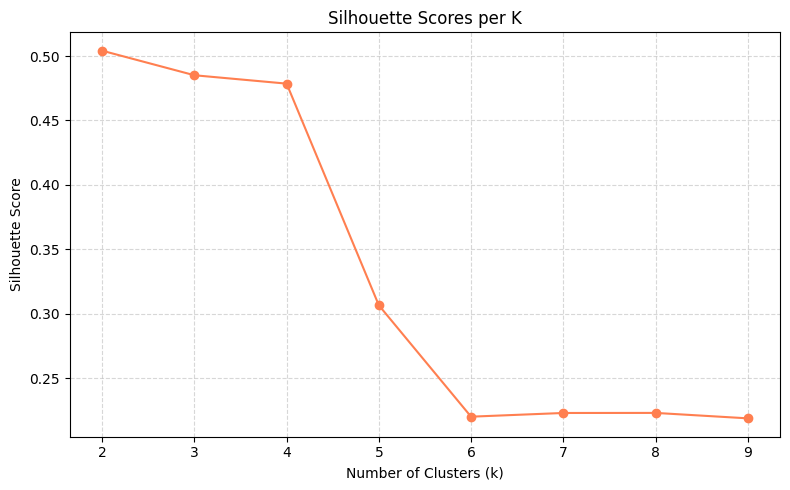

In [14]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"k={k} → Silhouette Score: {score:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='coral')
plt.title("Silhouette Scores per K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = km.fit_predict(X)

# See cluster sizes
print(df["Cluster"].value_counts().sort_index())

Cluster
0    70
1    16
2     8
3     1
Name: count, dtype: int64


In [16]:
import pandas as pd

cluster_summary = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=features
)
cluster_summary.index.name = "Cluster"
print(cluster_summary.round(3))

         Savings_Rate  Debt_to_Income  Spending_Ratio  Discretionary_Ratio  \
Cluster                                                                      
0               0.193           1.185           0.483                0.085   
1               0.582           2.146           1.193                0.203   
2               0.182           3.797           1.219                0.317   
3               0.775           8.975           1.976                0.565   

         Subscription_Ratio  
Cluster                      
0                     0.026  
1                     0.071  
2                     0.091  
3                     0.187  


In [17]:
persona_map = {
    0: "The Controlled Spender",
    1: "The Stretched Saver",
    2: "The Debt Burdened",
    3: "The High Risk Spender"
}

df["Persona"] = df["Cluster"].map(persona_map)

# Verify distribution
print(df["Persona"].value_counts())

Persona
The Controlled Spender    70
The Stretched Saver       16
The Debt Burdened          8
The High Risk Spender      1
Name: count, dtype: int64


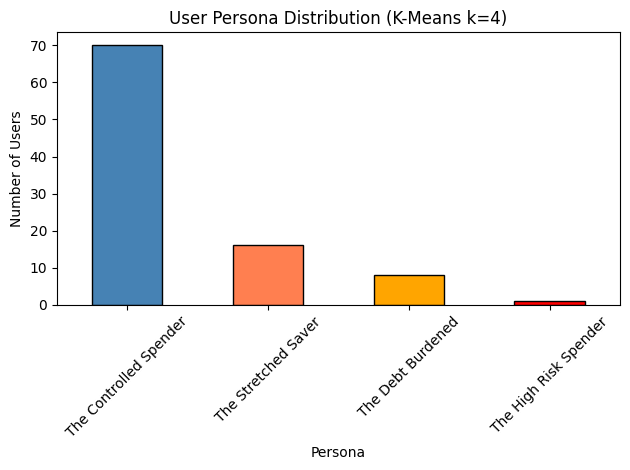

In [18]:
df["Persona"].value_counts().plot(
    kind="bar", 
    color=["steelblue", "coral", "orange", "red"],
    edgecolor="black"
)
plt.title("User Persona Distribution (K-Means k=4)")
plt.ylabel("Number of Users")
plt.xlabel("Persona")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
df["Monthly_Surplus"] = df["Monthly_Income"] - df["Total_Expenses"]
df["Required_Monthly"] = df["Target_Amount"] / df["Timeline_Months"]

In [20]:
def classify_feasibility(row):
    ratio = row["Monthly_Surplus"] / row["Required_Monthly"]
    
    if row["Monthly_Surplus"] <= 0:
        return "Not Feasible"
    elif ratio >= 1.0:
        return "Feasible"
    elif ratio >= 0.6:
        return "Partially Feasible"
    else:
        return "Not Feasible"

df["Goal_Feasibility"] = df.apply(classify_feasibility, axis=1)

# Check distribution
print(df["Goal_Feasibility"].value_counts())

Goal_Feasibility
Feasible              71
Not Feasible          21
Partially Feasible     3
Name: count, dtype: int64


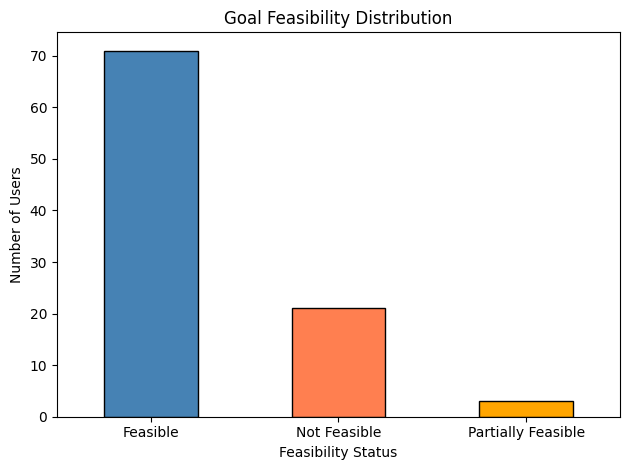

In [21]:
df["Goal_Feasibility"].value_counts().plot(
    kind="bar",
    color=["steelblue", "coral", "orange"],
    edgecolor="black"
)
plt.title("Goal Feasibility Distribution")
plt.ylabel("Number of Users")
plt.xlabel("Feasibility Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

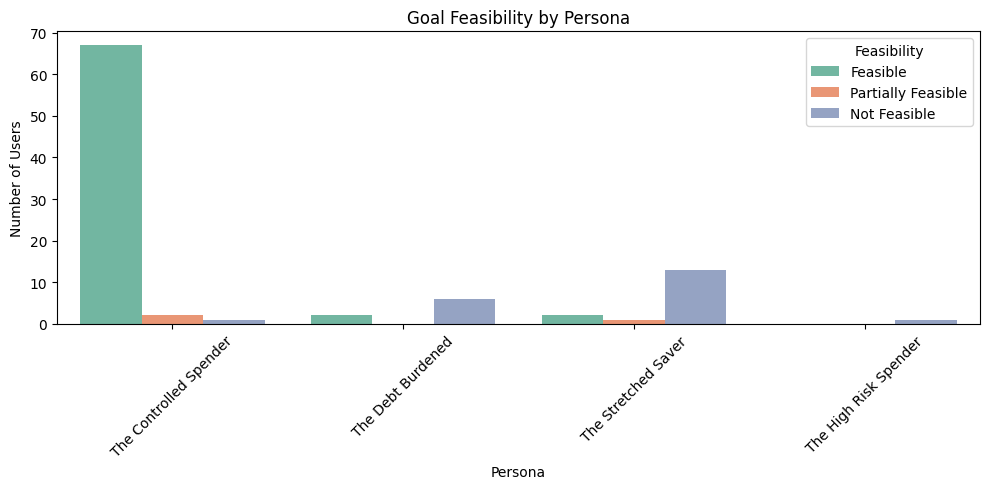

In [22]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Persona", hue="Goal_Feasibility", palette="Set2")
plt.title("Goal Feasibility by Persona")
plt.ylabel("Number of Users")
plt.xlabel("Persona")
plt.xticks(rotation=45)
plt.legend(title="Feasibility")
plt.tight_layout()
plt.show()

In [23]:
def generate_recommendations(row):
    recommendations = []
    persona = row["Persona"]
    feasibility = row["Goal_Feasibility"]
    savings_rate = row["Savings_Rate"]
    debt_ratio = row["Debt_to_Income"]
    spending_ratio = row["Spending_Ratio"]
    discretionary = row["Discretionary_Ratio"]
    subscription = row["Subscription_Ratio"]

    # ─────────────────────────────────────────
    # PERSONA-BASED RECOMMENDATIONS
    # ─────────────────────────────────────────

    if persona == "The Controlled Spender":
        recommendations.append("✅ Your spending is well controlled — great financial discipline.")
        if savings_rate < 0.20:
            recommendations.append("💰 Try increasing your savings rate to at least 20% of your income.")
        else:
            recommendations.append("📈 Consider moving surplus savings into a money market or investment account.")

    elif persona == "The Stretched Saver":
        recommendations.append("⚠️ You save well but your total spending exceeds your income — this is unsustainable.")
        recommendations.append("🔍 Review your largest expense categories and identify areas to cut by 10-15%.")
        if discretionary > 0.15:
            recommendations.append("🎮 Your discretionary spending is high — set a strict monthly entertainment budget.")

    elif persona == "The Debt Burdened":
        recommendations.append("🚨 Your debt-to-income ratio is critically high — debt repayment must be your priority.")
        recommendations.append("💳 Focus on paying off high-interest debt first using the avalanche method.")
        recommendations.append("🚫 Avoid taking on any new debt until your ratio drops below 0.4.")
        if savings_rate < 0.10:
            recommendations.append("💰 Even saving 5-10% consistently will build a buffer against further debt.")

    elif persona == "The High Risk Spender":
        recommendations.append("🔴 Your finances are in a critical state — immediate corrective action is needed.")
        recommendations.append("📉 Your spending is nearly double your income — create a strict budget immediately.")
        if subscription > 0.10:
            recommendations.append("📱 You have very high subscription costs — audit and cancel all non-essential subscriptions.")
        recommendations.append("🏦 Speak with a financial advisor about debt restructuring options.")

    # ─────────────────────────────────────────
    # GOAL FEASIBILITY RECOMMENDATIONS
    # ─────────────────────────────────────────

    if feasibility == "Feasible":
        recommendations.append(f"🏆 Your goal is achievable within your timeline — stay consistent!")
        if savings_rate > 0.50:
            recommendations.append("🌟 Excellent savings rate! You may even achieve your goal ahead of schedule.")

    elif feasibility == "Partially Feasible":
        recommendations.append("⏳ Your goal is partially achievable — you're about 60-99% of the way there.")
        recommendations.append("📊 Reducing monthly expenses by 10% could make your goal fully feasible.")
        recommendations.append("📅 Consider extending your goal timeline by 3-6 months as an alternative.")

    elif feasibility == "Not Feasible":
        recommendations.append("❌ Your goal is not achievable at your current savings pace.")
        recommendations.append("🔄 Options: increase income, reduce expenses, lower target amount, or extend timeline.")
        if spending_ratio > 1.0:
            recommendations.append("⚡ Critical: You are spending more than you earn — address this before pursuing any goal.")

    return recommendations

In [24]:
df["Recommendations"] = df.apply(generate_recommendations, axis=1)

# Preview recommendations for first 3 users
for i in range(3):
    print(f"\n{'='*60}")
    print(f"User {df['User_ID'].iloc[i]} | Persona: {df['Persona'].iloc[i]} | Feasibility: {df['Goal_Feasibility'].iloc[i]}")
    print(f"{'='*60}")
    for rec in df["Recommendations"].iloc[i]:
        print(f"  {rec}")


User 1 | Persona: The Controlled Spender | Feasibility: Feasible
  ✅ Your spending is well controlled — great financial discipline.
  📈 Consider moving surplus savings into a money market or investment account.
  🏆 Your goal is achievable within your timeline — stay consistent!

User 2 | Persona: The Controlled Spender | Feasibility: Feasible
  ✅ Your spending is well controlled — great financial discipline.
  💰 Try increasing your savings rate to at least 20% of your income.
  🏆 Your goal is achievable within your timeline — stay consistent!

User 3 | Persona: The Controlled Spender | Feasibility: Feasible
  ✅ Your spending is well controlled — great financial discipline.
  📈 Consider moving surplus savings into a money market or investment account.
  🏆 Your goal is achievable within your timeline — stay consistent!


In [25]:
# Count average recommendations per persona
df["Rec_Count"] = df["Recommendations"].apply(len)

print(df.groupby("Persona")["Rec_Count"].mean().round(1))
print(f"\nTotal users with recommendations: {len(df)}")
print(f"Average recommendations per user: {df['Rec_Count'].mean():.1f}")

Persona
The Controlled Spender    3.1
The Debt Burdened         5.8
The High Risk Spender     7.0
The Stretched Saver       5.4
Name: Rec_Count, dtype: float64

Total users with recommendations: 95
Average recommendations per user: 3.7


In [26]:
summary = df.groupby(["Persona", "Goal_Feasibility"]).size().reset_index(name="Count")
print(summary)

                  Persona    Goal_Feasibility  Count
0  The Controlled Spender            Feasible     67
1  The Controlled Spender        Not Feasible      1
2  The Controlled Spender  Partially Feasible      2
3       The Debt Burdened            Feasible      2
4       The Debt Burdened        Not Feasible      6
5   The High Risk Spender        Not Feasible      1
6     The Stretched Saver            Feasible      2
7     The Stretched Saver        Not Feasible     13
8     The Stretched Saver  Partially Feasible      1


In [27]:
import joblib
import os

# Create models folder
os.makedirs("C:/Users/Administrator/Documents/My Documents/my_school_project/models", exist_ok=True)

# Save the model and scaler
joblib.dump(km, "C:/Users/Administrator/Documents/My Documents/my_school_project/models/kmeans_model.pkl")
joblib.dump(scaler, "C:/Users/Administrator/Documents/My Documents/my_school_project/models/scaler.pkl")

print("✅ Model saved successfully!")
print(f"   Number of clusters: {km.n_clusters}")
print(f"   Features used: {features}")

✅ Model saved successfully!
   Number of clusters: 4
   Features used: ['Savings_Rate', 'Debt_to_Income', 'Spending_Ratio', 'Discretionary_Ratio', 'Subscription_Ratio']
